## 1. Introduction

Exploratory Data Analysis (EDA) is the first step in a data science project. It focuses on exploring data to understand its main characteristics before applying statistical models or drawing conclusions.

EDA uses summary statistics, such as the mean, median, and quantiles, together with visualizations, such as boxplots and scatterplots, to help reveal patterns, distributions, unusual observations, and relationships within a dataset.

The chapter introduces practical methods for summarizing data and exploring relationships between variables.


## 2. Elements of Structured Data

Structured data is information organized in a defined format, making it easier to store, analyze, and process using computational tools.

In data science, structured data commonly includes numerical and categorical variables. Numerical variables represent measurable quantities, while categorical variables represent groups or labels.

Understanding the type of data is important because it determines which statistical summaries and visualizations are appropriate.

### Types of Structured Data

* **Numerical data:** Values that represent quantities, such as height, weight, or income.
* **Categorical data:** Values that represent categories, such as product type, city, or customer status.
* **Ordinal data:** Categorical values with a meaningful order, such as low, medium, and high.
* **Binary data:** Data with only two possible categories, such as yes/no or true/false.

### Summary

Identifying data types is an important first step in Exploratory Data Analysis (EDA), because different types of data require different methods of analysis.


## 3. Rectangular Data

Rectangular data is organized in rows and columns. Each row represents an observation, while each column represents a variable.

A common example is a pandas DataFrame, which is frequently used to store and analyze tabular data in Python.

A DataFrame can contain numerical and categorical columns. Understanding its dimensions, column names, and data types is an important step in Exploratory Data Analysis.


In [1]:
import pandas as pd

data = {
    "Product": ["A", "B", "C", "D", "E", "F"],
    "Sales": [120, 150, 100, 180, 130, 160],
    "Price": [20, 25, 18, 30, 22, 27],
    "Category": ["Food", "Drink", "Food", "Drink", "Food", "Drink"]
}

df = pd.DataFrame(data)

print("First five rows:")
display(df.head())

print("Dataset dimensions:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First five rows:


,Product,Sales,Price,Category
0,A,120,20,Food
1,B,150,25,Drink
2,C,100,18,Food
3,D,180,30,Drink
4,E,130,22,Food


Dataset dimensions: (6, 4)

Column names:
['Product', 'Sales', 'Price', 'Category']

Data types:
Product     object
Sales        int64
Price        int64
Category    object
dtype: object


### Code Explanation and Results

* `pd.DataFrame()` creates a rectangular dataset.
* `head()` displays the first five rows.
* `shape` returns the number of rows and columns.
* `columns` displays the variable names.
* `dtypes` identifies the data type of each column.

The dataset contains six observations and three variables plus the product identifier. The `Sales` and `Price` columns are numerical, while `Product` and `Category` are categorical identifiers.


## 4. Estimates of Location

Estimates of location describe the central or typical value of a dataset.

Common measures include:

* **Mean:** The arithmetic average of the observations.
* **Median:** The middle value after the observations are sorted.
* **Weighted mean:** An average in which observations receive different weights.
* **Trimmed mean:** A mean calculated after removing a specified proportion of the smallest and largest observations.

The mean is sensitive to extreme values, while the median is generally more resistant to them.


In [2]:
import numpy as np

sales = df["Sales"]

mean_sales = sales.mean()
median_sales = sales.median()
weighted_mean_sales = np.average(
    sales,
    weights=df["Price"]
)
trimmed_mean_sales = sales.sort_values().iloc[1:-1].mean()

print("Mean:", mean_sales)
print("Median:", median_sales)
print("Weighted mean:", weighted_mean_sales)
print("Trimmed mean:", trimmed_mean_sales)

Mean: 140.0
Median: 140.0
Weighted mean: 144.57746478873239
Trimmed mean: 140.0


### Code Explanation and Results

The code calculates four measures of location for the sales variable.

* The mean gives the arithmetic average.
* The median gives the middle value.
* The weighted mean gives greater influence to observations with larger weights. Here, price is used as an illustrative weight.
* The trimmed mean excludes the smallest and largest observations before calculating the average.

These measures describe the center of the data in different ways. The choice depends on the purpose of the analysis and the presence of extreme values.


## 5. Estimates of Variability

Estimates of variability describe how spread out the observations are.

Common measures include:

* **Range:** The difference between the maximum and minimum values.
* **Interquartile range (IQR):** The difference between the third quartile and the first quartile.
* **Variance:** A measure based on squared deviations from the mean.
* **Standard deviation:** The square root of the variance.
* **Mean absolute deviation:** The average absolute distance from the mean.

Measures of variability complement measures of location because two datasets can have similar averages but very different spreads.


In [3]:
sales_range = sales.max() - sales.min()
q1 = sales.quantile(0.25)
q3 = sales.quantile(0.75)
iqr = q3 - q1
variance = sales.var()
std_dev = sales.std()
mad = (sales - sales.mean()).abs().mean()

print("Range:", sales_range)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Sample variance:", variance)
print("Sample standard deviation:", std_dev)
print("Mean absolute deviation:", mad)

Range: 80
Q1: 122.5
Q3: 157.5
IQR: 35.0
Sample variance: 840.0
Sample standard deviation: 28.982753492378876
Mean absolute deviation: 23.333333333333332


### Code Explanation and Results

The code calculates several measures of spread.

* `max() - min()` calculates the range.
* `quantile()` calculates quartiles.
* `IQR` measures the spread of the middle 50% of observations.
* `var()` calculates the sample variance.
* `std()` calculates the sample standard deviation.
* The absolute-deviation calculation measures the average absolute distance from the mean.

A larger spread indicates that the observations are more dispersed. The IQR is less affected by extreme values than the range.


## 6. Exploring Data Distribution

A data distribution describes how values are spread across a variable.

Histograms group numerical values into intervals and display their frequencies. Boxplots summarize the median, quartiles, and potential outliers. Density plots provide a smoothed representation of a distribution.

Visualizing a distribution helps identify skewness, clusters, gaps, and unusually high or low observations.


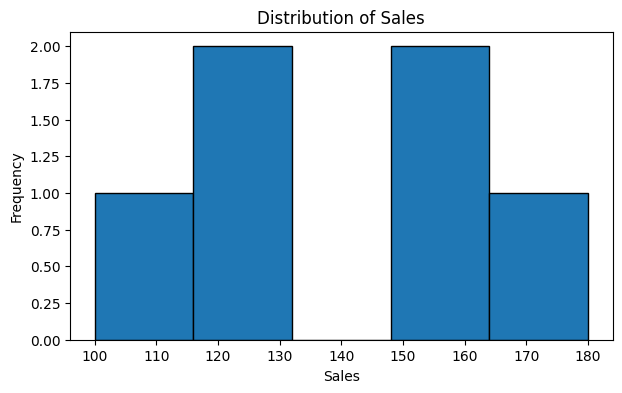

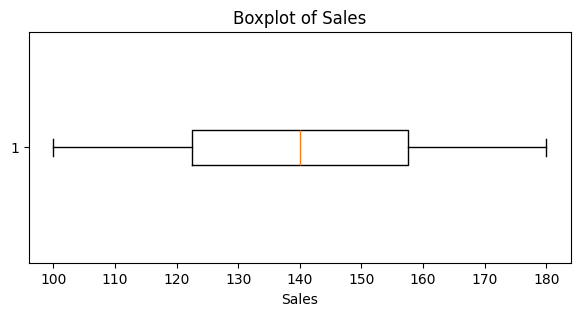

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(sales, bins=5, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 3))
plt.boxplot(sales, vert=False)
plt.title("Boxplot of Sales")
plt.xlabel("Sales")
plt.show()

### Code Explanation and Results

The histogram displays the frequency of sales values across intervals. The boxplot summarizes the distribution using the median and quartiles.

These visualizations help identify the general spread of sales and reveal whether any observations may be unusually high or low. A potential outlier identified by a boxplot should be investigated rather than automatically removed.


## 7. Exploring Binary and Categorical Data

Categorical data represents groups rather than numerical measurements. Binary data is a special case with two possible categories.

Frequency tables count how often each category occurs. Proportions express each category's frequency as a fraction of the total.

Bar charts are useful for comparing the frequencies of categorical values. These methods help identify the most common categories and imbalances in the data.


Category frequencies:
Category
Food     3
Drink    3
Name: count, dtype: int64

Category proportions:
Category
Food     0.5
Drink    0.5
Name: proportion, dtype: float64


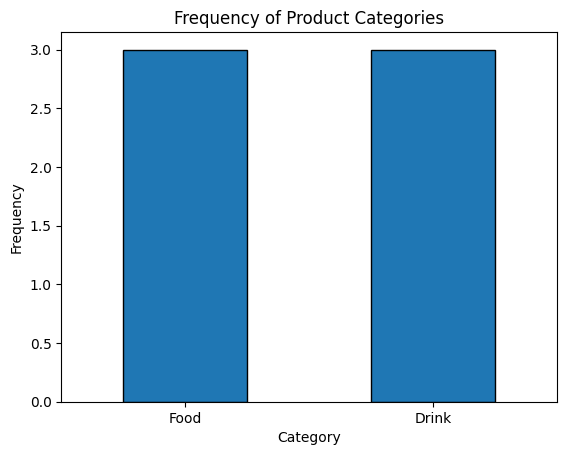

In [5]:
category_counts = df["Category"].value_counts()
category_proportions = df["Category"].value_counts(normalize=True)

print("Category frequencies:")
print(category_counts)

print("\nCategory proportions:")
print(category_proportions)

category_counts.plot(kind="bar", edgecolor="black")
plt.title("Frequency of Product Categories")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

### Code Explanation and Results

* `value_counts()` counts observations in each category.
* `value_counts(normalize=True)` calculates the proportion of each category.
* The bar chart compares category frequencies visually.

In this example, Food and Drink occur equally often. Frequency tables and bar charts are useful for examining categorical variables before further analysis.


## 8. Correlation

Correlation measures the strength and direction of an association between two numerical variables.

The Pearson correlation coefficient ranges from -1 to +1.

* A value near +1 indicates a strong positive linear association.
* A value near -1 indicates a strong negative linear association.
* A value near 0 indicates little or no linear association.

Correlation does not establish causation. Two variables can be associated without one directly causing the other.


Correlation matrix:


,Sales,Price
Sales,1.000000,0.996351
Price,0.996351,1.000000


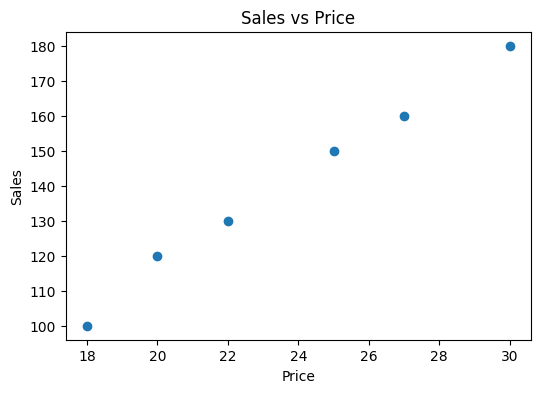

In [6]:
correlation = df[["Sales", "Price"]].corr()

print("Correlation matrix:")
display(correlation)

plt.figure(figsize=(6, 4))
plt.scatter(df["Price"], df["Sales"])
plt.title("Sales vs Price")
plt.xlabel("Price")
plt.ylabel("Sales")
plt.show()

### Code Explanation and Results

The `corr()` method calculates the Pearson correlation coefficient for the numerical variables.

The scatterplot shows the relationship between price and sales. In this illustrative dataset, higher prices generally occur alongside higher sales values.

This pattern describes an association in the example data. It does not demonstrate that increasing price causes sales to increase.


## 9. Exploring Two or More Variables

Analyzing variables together can reveal relationships that are not apparent when each variable is examined separately.

Examples include:

* Numerical versus numerical: scatterplots and correlation coefficients.
* Categorical versus numerical: comparing numerical summaries across categories.
* Categorical versus categorical: comparing category frequencies using a contingency table.

The analysis should consider the type of each variable and the question being investigated.


In [7]:
print("Sales summary by category:")
display(
    df.groupby("Category")["Sales"].agg(
        ["count", "mean", "median", "min", "max"]
    )
)

print("Contingency table:")
display(pd.crosstab(df["Category"], df["Product"]))

Sales summary by category:


,count,mean,median,min,max
Category,,,,,
Drink,3,163.333333,160.0,150,180
Food,3,116.666667,120.0,100,130


Contingency table:


Product,A,B,C,D,E,F
Category,,,,,,
Drink,0,1,0,1,0,1
Food,1,0,1,0,1,0


## 10. Summary

Exploratory Data Analysis is an important part of data science because it helps analysts understand data before building statistical models.

This chapter introduced several key techniques:

1. Identifying structured data and its variables.
2. Organizing observations using rectangular data structures.
3. Measuring location using the mean, median, and other averages.
4. Measuring variability using the range, IQR, variance, and standard deviation.
5. Exploring distributions using histograms and boxplots.
6. Summarizing categorical data using frequency tables and bar charts.
7. Examining associations using correlation and scatterplots.
8. Exploring relationships between multiple variables using grouping and contingency tables.

These techniques help reveal patterns, variation, unusual observations, and relationships in a dataset. The results of EDA can guide later statistical analysis and model development.

**Note:** The code examples in this notebook use an illustrative dataset created for demonstration. They are supplementary implementations, not a verbatim reproduction of every example in the textbook.
